## Subscription Behavior Analysis
### Business Objective

A SaaS company wants to better understand its customers, subscriptions, payments, and economic conditions.

This project looks at:

Customer industries and company sizes
Subscription renewal rates
Payment amounts and methods
Economic conditions during subscription periods

The goal is to identify patterns in customer subscription behavior.

### Questions

This analysis will answer:

How many Fintech and Crypto clients are there?
Which industry has the highest renewal rate?
Do renewal rates differ by subscription type and company size?
What payment methods do customers use, and how much do they pay?
What is the average inflation rate during renewal periods?
How do economic conditions differ between customers who renewed and those who did not?

### Dataset Overview

Four datasets are used in this analysis.

### `client_details.csv`

Contains information about each client:

* `client_id`: Unique identifier for each client
* `company_size`: Size of the company
* `industry`: Industry of the client
* `location`: Location of the client

### `subscription_records.csv`

Contains information about customer subscriptions:

* `client_id`: Unique identifier for each client
* `subscription_type`: Monthly or Yearly subscription
* `start_date`: Subscription start date
* `end_date`: Subscription end date
* `renewed`: Whether the subscription was renewed

### `payment_history.csv`

Contains payment information:

* `client_id`: Unique identifier for each client
* `payment_date`: Date of the payment
* `amount_paid`: Amount paid
* `payment_method`: Method used to make the payment

### `economic_indicators.csv`

Contains quarterly economic information:

* `start_date`: Start date of the economic period
* `end_date`: End date of the economic period
* `inflation_rate`: Inflation rate during the period
* `gdp_growth_rate`: GDP growth rate during the period


### Data Quality Checks

Before beginning the analysis, the datasets were checked for:

- Missing values
- Duplicate records
- Data types
- Date ranges
- Matching client IDs between datasets
- Coverage of the economic data

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import data and convert date columns from string to datetime
client_details = pd.read_csv('datasets/client_details.csv')

subscription_records = pd.read_csv(
    'datasets/subscription_records.csv', 
    parse_dates = ['start_date','end_date'])

economic_indicators = pd.read_csv(
    'datasets/economic_indicators.csv', 
    parse_dates = ['start_date','end_date'])

payment_history = pd.read_csv(
    'datasets/payment_history.csv',
    parse_dates=['payment_date'])

In [3]:
client_details.isna().sum()

client_id       0
company_size    0
industry        0
location        0
dtype: int64

In [4]:
subscription_records.isna().sum()

client_id            0
subscription_type    0
start_date           0
end_date             0
renewed              0
dtype: int64

In [5]:
economic_indicators.isna().sum()

Unnamed: 0         0
start_date         0
end_date           0
inflation_rate     0
gdp_growth_rate    0
dtype: int64

In [6]:
payment_history.isna().sum()

client_id         0
payment_date      0
amount_paid       0
payment_method    0
dtype: int64

In [7]:
client_details['client_id'].duplicated().sum()

0

In [8]:
subscription_records['client_id'].duplicated().sum()

0

In [9]:
payment_history['client_id'].duplicated().sum()

0

In [10]:
subscription_records['start_date'].min()
subscription_records['start_date'].max()

Timestamp('2022-12-20 00:00:00')

In [11]:
subscription_records['start_date'].max()

Timestamp('2022-12-20 00:00:00')

In [12]:
subscription_records['end_date'].min()

Timestamp('2018-04-03 00:00:00')

In [13]:
subscription_records['end_date'].max()

Timestamp('2023-12-20 00:00:00')

In [14]:
economic_indicators['start_date'].min()

Timestamp('2018-01-01 00:00:00')

In [15]:
economic_indicators['start_date'].max()

Timestamp('2023-01-01 00:00:00')

In [16]:
economic_indicators['end_date'].min()

Timestamp('2018-03-31 00:00:00')

In [17]:
economic_indicators['end_date'].max()

Timestamp('2023-01-03 00:00:00')

In [18]:
set(subscription_records['client_id']) - set(client_details['client_id'])

set()

In [19]:
set(client_details['client_id']) - set(subscription_records['client_id'])

set()

In [20]:
set(client_details['client_id']) - set(payment_history['client_id'])

set()

In [21]:
set(payment_history['client_id']) - set(client_details['client_id'])

set()

In [22]:
set(subscription_records['client_id']) - set(payment_history['client_id'])

set()

In [23]:
set(payment_history['client_id']) - set(subscription_records['client_id'])

set()

In [24]:
# 1. How many total Fintech and Crypto clients do they have?
fintech_crypto = client_details[
    client_details['industry'].isin(['Fintech', 'Crypto'])
]

total_fintech_crypto_clients = fintech_crypto['client_id'].nunique()

total_fintech_crypto_clients

47

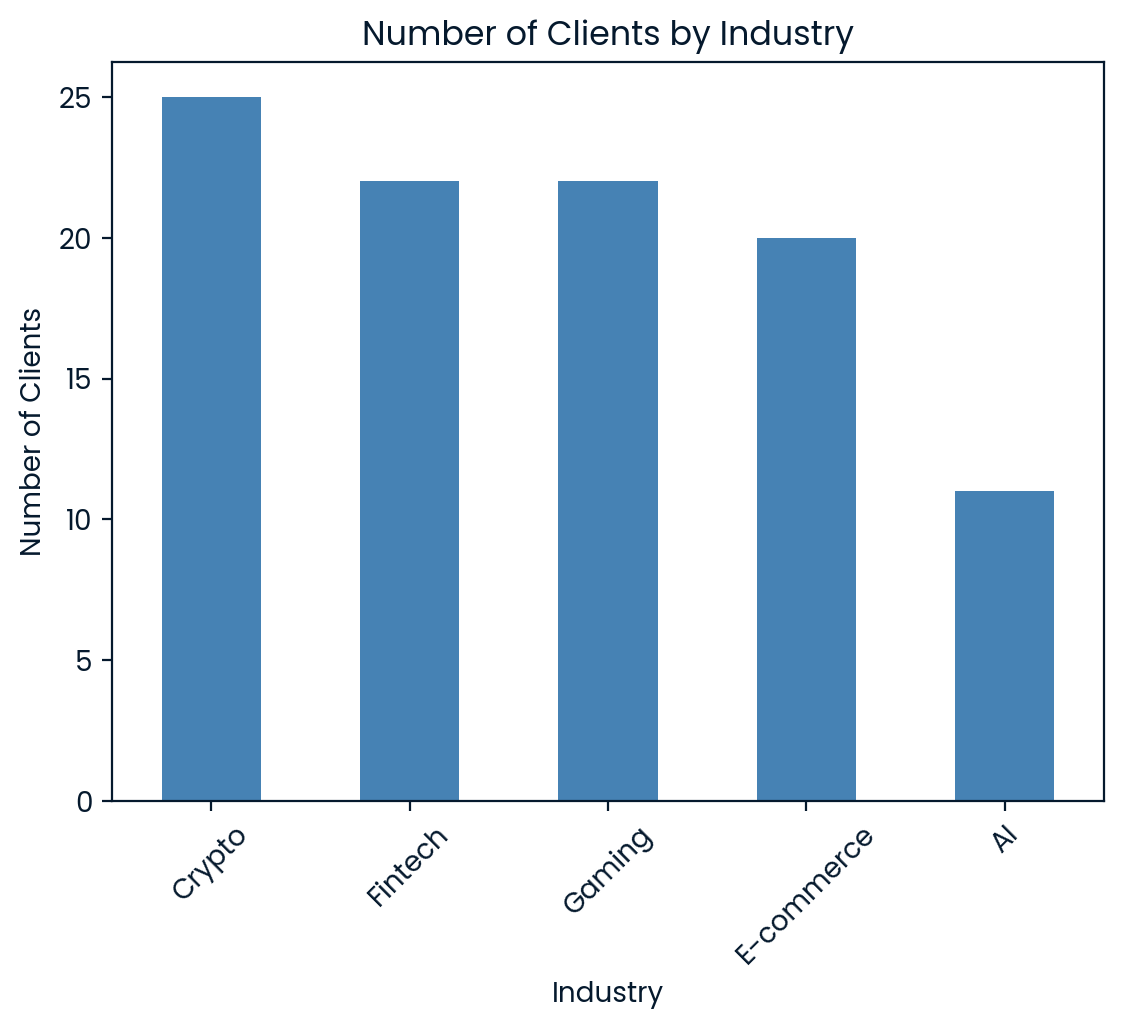

In [25]:
client_details['industry'].value_counts().plot(kind='bar', color = '#4682B4')
plt.title('Number of Clients by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Clients')
plt.xticks(rotation = 45)
plt.show()

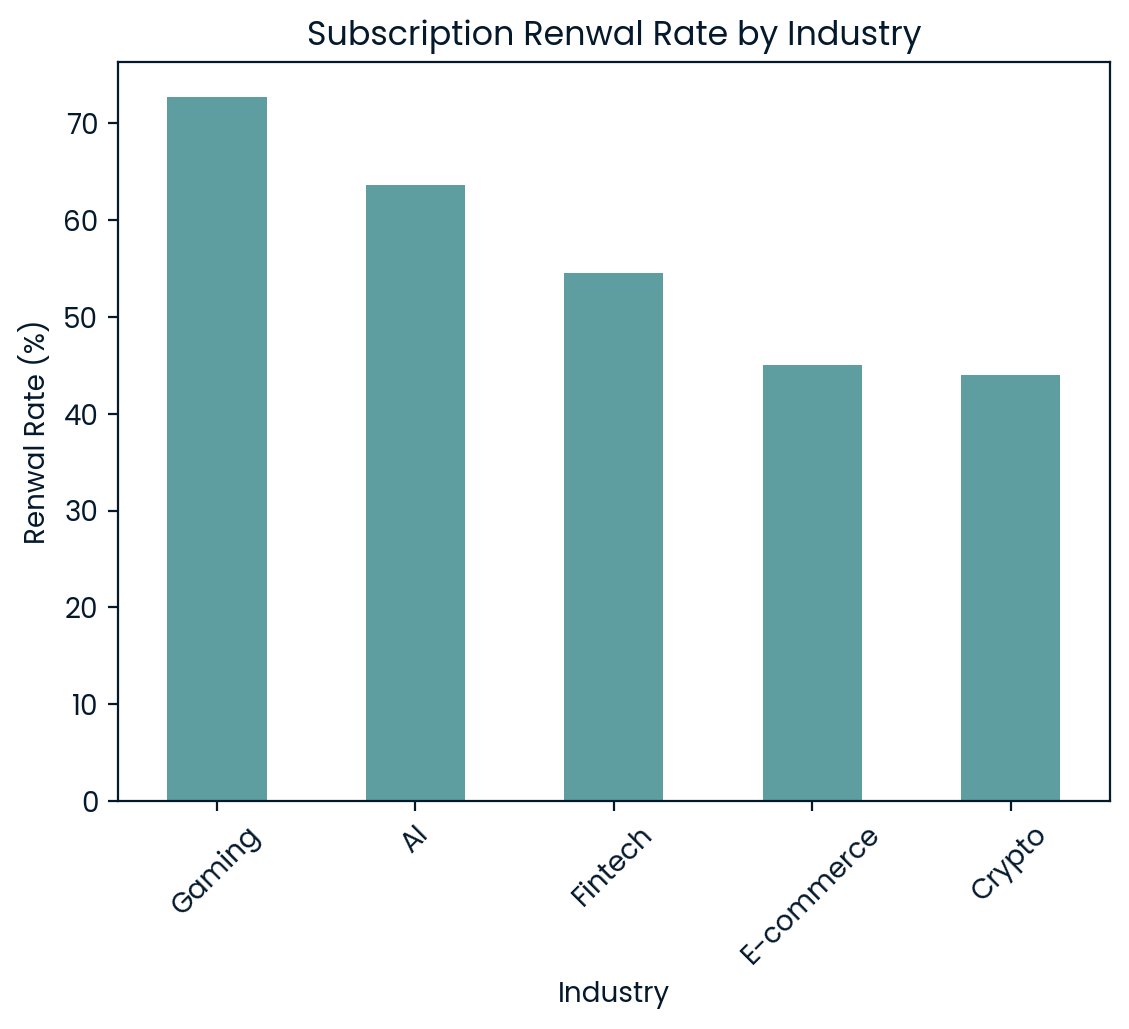

In [26]:
# 2. Which industry has the highest renewal rate?

# Merge the client_details and subscription_records
client_subs = (client_details
               .merge(subscription_records, 
                      on = 'client_id', 
                      how = 'left'))

# Calculate the average renewal rate for each industry
industry_renewal_rate = (client_subs
                         .groupby('industry')['renewed']
                         .agg('mean')
                         .sort_values(ascending = False))

industry_renewal_rate = (industry_renewal_rate*100).round(2)
industry_renewal_rate.plot(kind='bar', color = 'cadetblue')
plt.title('Subscription Renwal Rate by Industry')
plt.xlabel('Industry')
plt.ylabel('Renwal Rate (%)')
plt.xticks(rotation = 45)
plt.show()

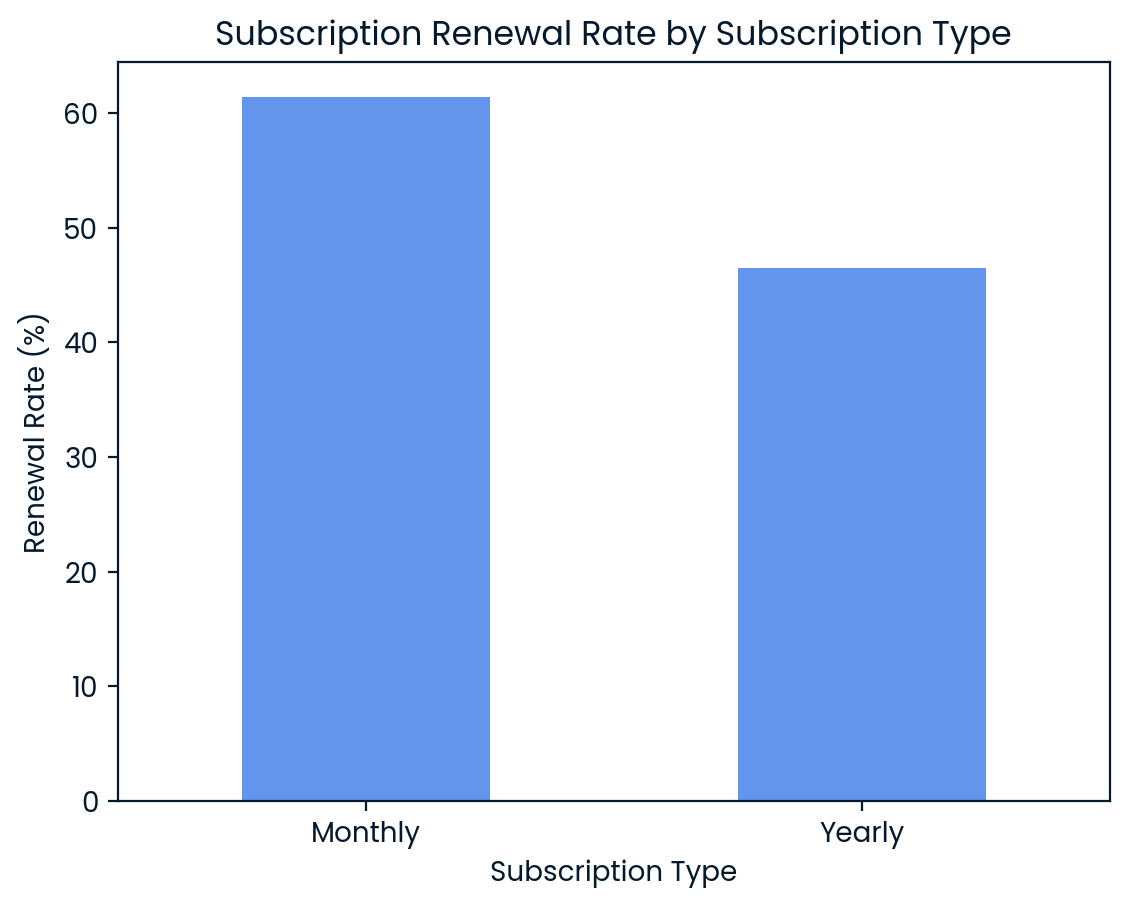

In [27]:
# 3. Renewal Rate by Subscription Type
client_subs.head()

subtype_renewal = (client_subs.groupby('subscription_type')['renewed'].agg('mean'))
subtype_renewal = (subtype_renewal*100).round(2)
subtype_renewal.plot(kind = 'bar', color = 'cornflowerblue')
plt.title('Subscription Renewal Rate by Subscription Type')
plt.ylabel('Renewal Rate (%)')
plt.xlabel('Subscription Type')
plt.xticks(rotation = 0)
plt.show()

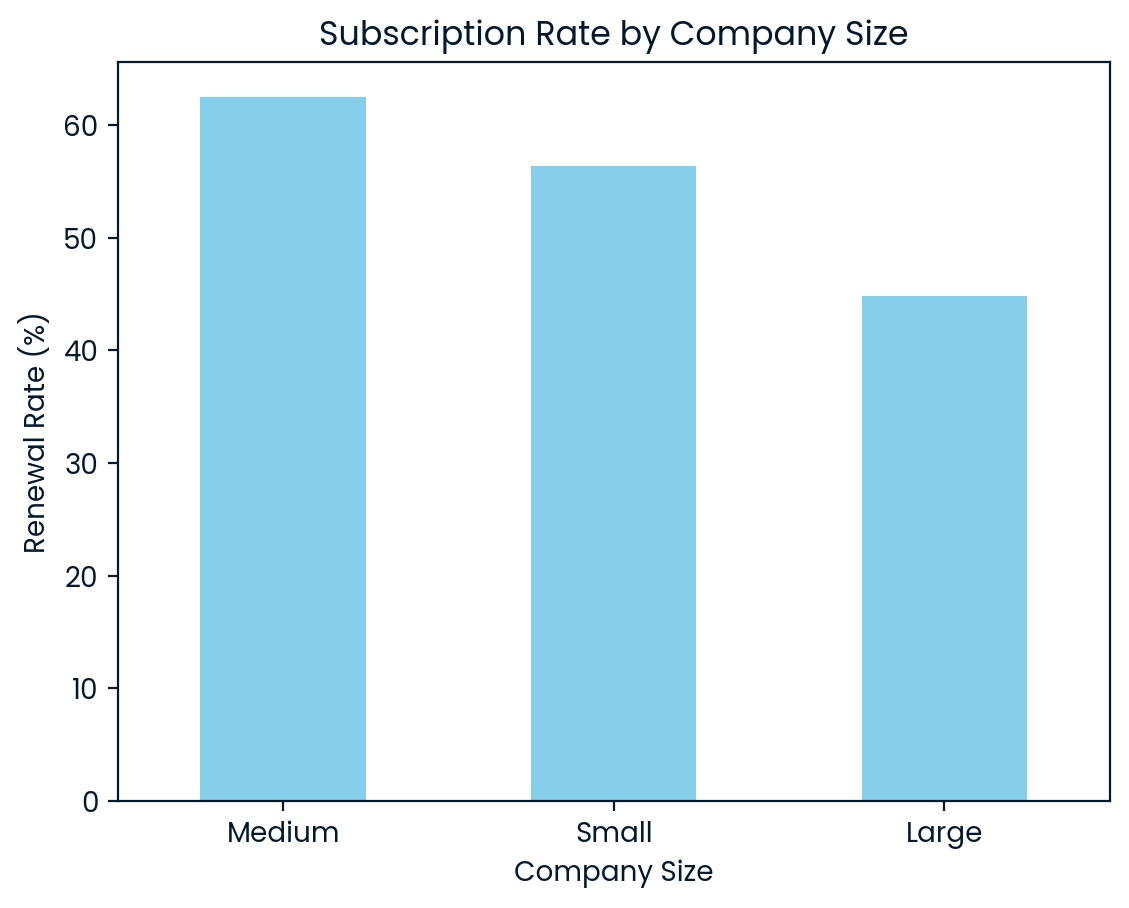

In [28]:
# 4. Renewal Rate by company size
client_subs.head()
compsize_renewal = ((client_subs
                    .groupby('company_size')['renewed']
                    .agg('mean')*100)
                    .round(2)
                    .sort_values(ascending=False))

compsize_renewal.plot(kind = 'bar', color = '#87CEEB')
plt.title('Subscription Rate by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Renewal Rate (%)')
plt.xticks(rotation = 0)
plt.show()

### Payment Analysis

The payment dataset was analyzed to understand customer payment behavior, including payment methods and payment amounts.

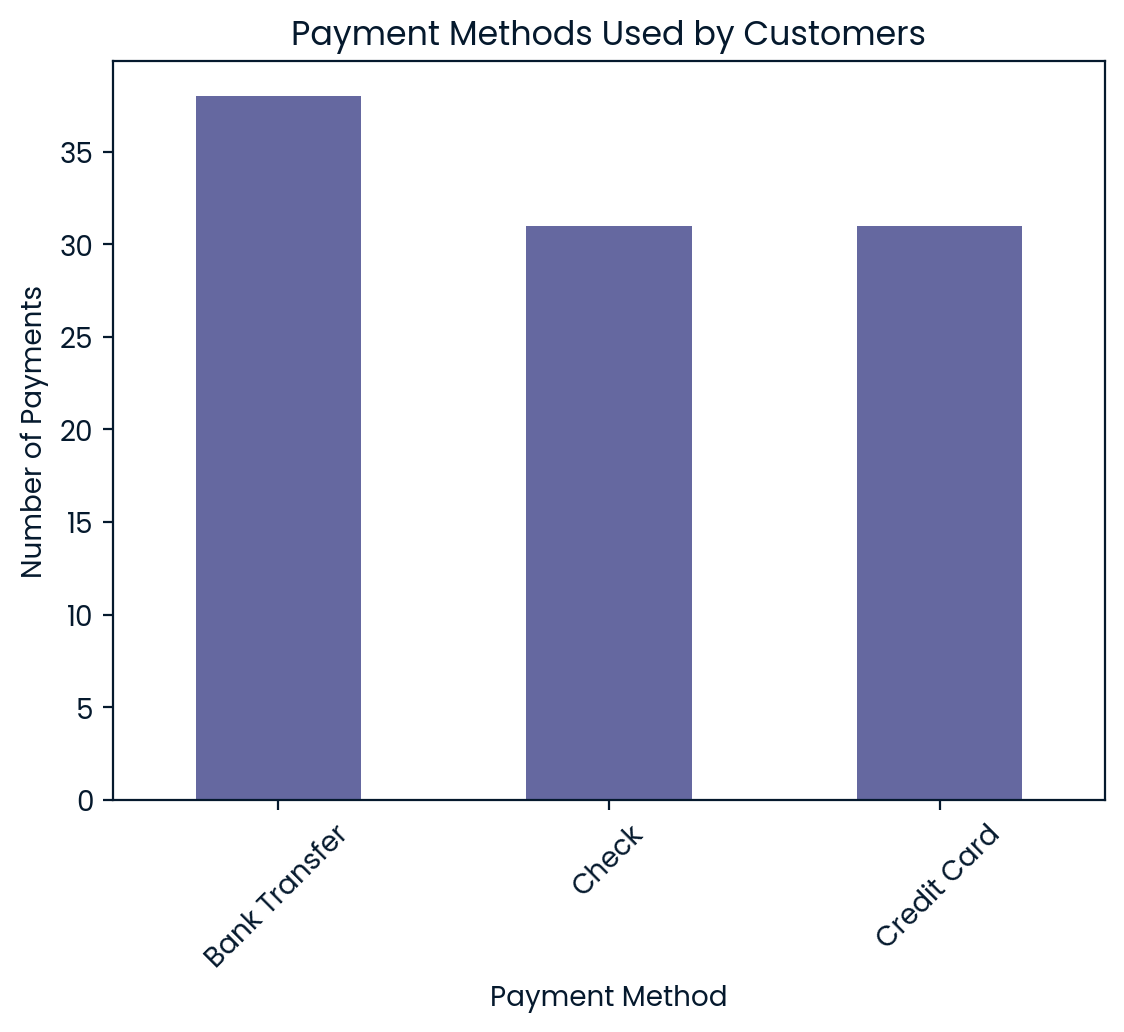

In [29]:
# 5. Which payment method is the most common?

payment_history['payment_method'].value_counts().plot(kind = 'bar')
plt.title('Payment Methods Used by Customers')
plt.xlabel('Payment Method')
plt.ylabel('Number of Payments')
plt.xticks(rotation = 45)
plt.show()

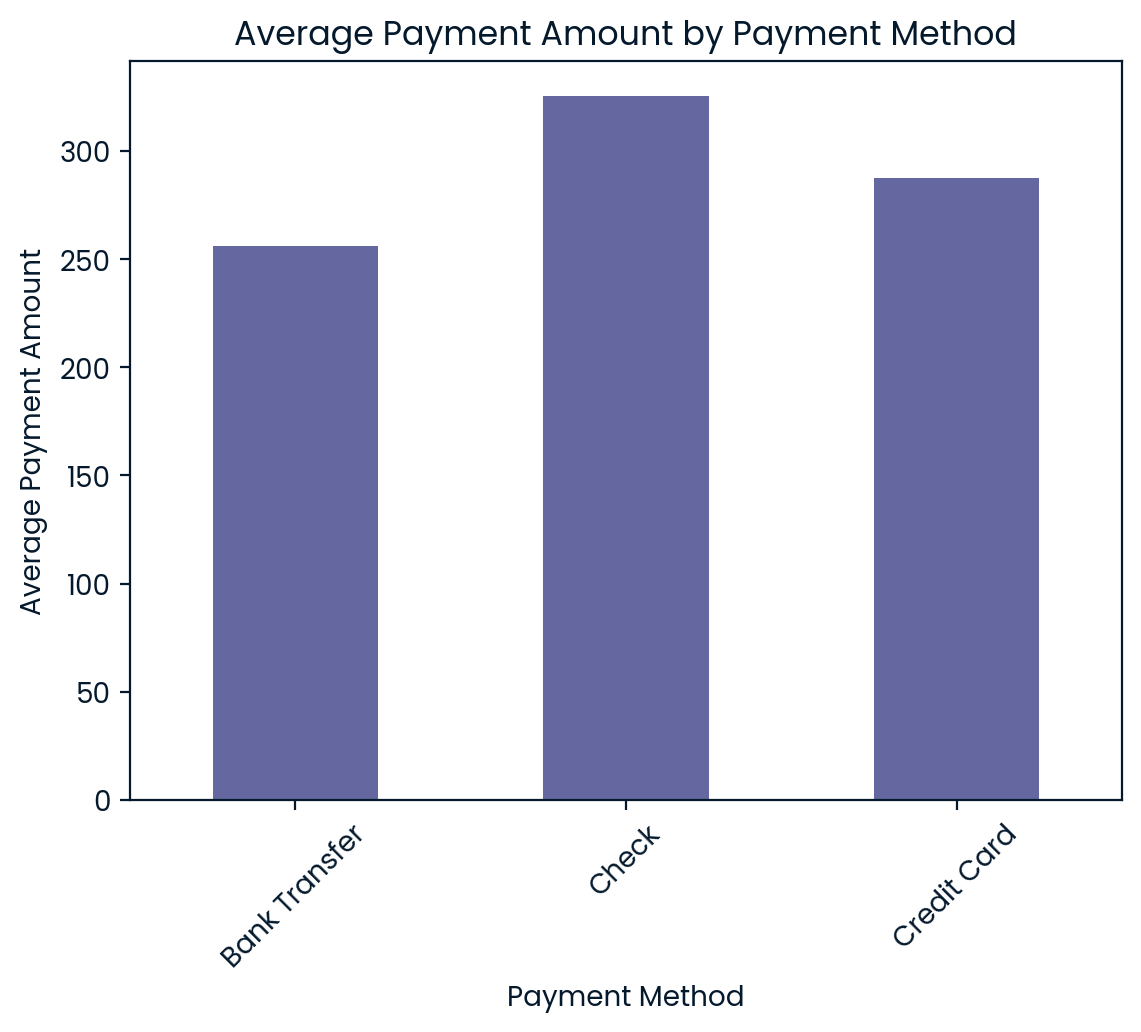

In [30]:
# 6. Average payment amount by payment method

(((payment_history
     .groupby('payment_method')['amount_paid']
     .agg('mean'))
     .round(2))
     .plot(kind = 'bar'))
plt.title('Average Payment Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Payment Amount')
plt.xticks(rotation = 45)
plt.show()

In [31]:
# 7. What is the average payment amount by industry

client_payments = client_details.merge(
    payment_history,
    on = 'client_id',
    how = 'left'
)
((client_payments
  .groupby('industry')['amount_paid']
  .agg('mean')*100)
  .round(2)
  .rename('average_amount_paid'))

industry
AI            26050.00
Crypto        30588.80
E-commerce    30324.50
Fintech       28918.18
Gaming        26305.91
Name: average_amount_paid, dtype: float64

In [32]:
# 8. Average payment amount for customers who renewed compared with customers who did not renew?

(subscription_records
 .merge(
    payment_history,
    on = 'client_id',
    how = 'left')
 .groupby('renewed')['amount_paid']
 .agg('mean')
 .round(2))

renewed
False    295.23
True     280.75
Name: amount_paid, dtype: float64

In [45]:
# 9. For clients who renewed their subscriptions, what was the average inflation rate when their subscriptions were renewed?

# Sort subscription_records by ascending end_date
subs_sorted = subscription_records.sort_values(by = 'end_date', ascending = True).reset_index(drop=True)

# Sort economic_indicators by ascending start_date
econ_sorted = economic_indicators.sort_values(by = 'start_date', ascending = True).reset_index(drop=True)

# Match each subscription end date(renewal date) with 
# the most recent available economic period
sub_econ_merged = pd.merge_asof(subs_sorted,econ_sorted, 
                                left_on = 'end_date', 
                                right_on = 'start_date', 
                                direction = 'backward')

# Calculate average inflation rate and average gdp growth rate 
# for customers who renewed and those that didn't renew

avg_indicators = (sub_econ_merged
                  .groupby('renewed')[['inflation_rate', 'gdp_growth_rate']]
                  .agg('mean')
                  .round(2)
                  .rename(
                      columns = {
                          'inflation_rate': 'avg_inflation_rate',
                          'gdp_growth_rate':'avg_gdp_growth_rate'}
                  )
                 )
avg_indicators

,avg_inflation_rate,avg_gdp_growth_rate
renewed,,
False,4.84,2.42
True,4.42,2.28


The average inflation rate and average GDP growth rate for customers who renewed their subscriptions were slightly lower than those for customers who did not renew, by 0.42 and 0.14 percentage points, respectively. These results do not establish a causal relationship, and the relatively small differences suggest that there is no strong or meaningful relationship between these economic indicators and subscription renewals in this analysis.

### Key Findings

The analysis found several patterns in customer subscription behavior.

- There are 47 Fintech and Crypto clients.
- Renewal rates differ across industries.
- Renewal rates differ by subscription type and company size.
- Payment amounts and payment methods vary across customers.
- Economic conditions provide additional context for subscription renewals.
- The results show relationships in the data but do not prove cause and effect.

### Limitations

- Economic data covers specific periods, while subscription end dates are specific days.

- Economic data is not available for every subscription period.

- Payment dates should not automatically be considered renewal dates.

- The analysis shows patterns in the data but does not prove that economic conditions or payment amounts caused customers to renew.

### Conclusion

This project analyzed customer information, subscription renewals, payment behavior, and economic conditions using four datasets.

The results provide a better understanding of customer subscription behavior and the factors associated with renewals.

More complete data and a larger dataset could provide further insight into customer retention.